**1.Problem Statement**

**2.Import Libraries**

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix

**3. Data Loading**

In [2]:
df=pd.read_csv("shop_smart_ecommerce.csv")

In [3]:
df

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.000000,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.000000,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.000000,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False


In [4]:
#Feature Target Split
X=df.drop(columns=["Revenue"])
y=df["Revenue"].astype(int)

**4. Exploratory Data Analysis (EDA)**

In [5]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

Text(0.5, 1.0, 'no purchase or purshase')

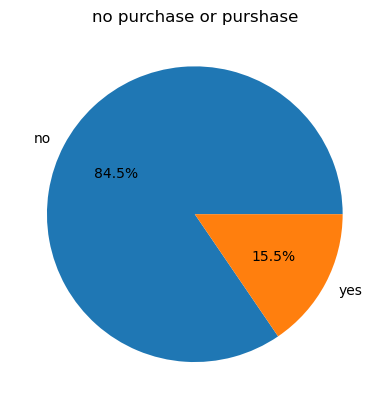

In [6]:
import matplotlib.pyplot as plt
classes_count=df["Revenue"].value_counts()
plt.pie(classes_count,labels=["no","yes"],autopct="%1.1f%%")
plt.title("no purchase or purshase")

The dataset is imbalanced with significantly fewer positive purchase instances.

**5.Feature Type Separation**

In [7]:
num_features = X.select_dtypes(include=["int64", "float64"]).columns
cat_features = X.select_dtypes(include=["object", "category"]).columns
num_features = list(num_features)
cat_features = list(cat_features)

**6.Train-Test Split**

In [8]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**7.Preprocessing + Pipeline**

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
    ]
)

pipe = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", DecisionTreeClassifier(random_state=42))
    ]
)

**8.Hyperparameter Tuning**

In [10]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__max_depth": [None, 4, 6, 8, 10],
    "model__min_samples_leaf": [20, 30, 50],
    "model__class_weight": [None, "balanced"]
}

grid = GridSearchCV(
    pipe,
    param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best F1 (CV):", grid.best_score_)
print("Best Params:", grid.best_params_)

Best F1 (CV): 0.6571226659281593
Best Params: {'model__class_weight': None, 'model__max_depth': 4, 'model__min_samples_leaf': 20}


**9. Base Model Evaluation**

In [11]:
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    precision_score, recall_score,
    f1_score, classification_report
)

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print("\n--- Base Model ---")
base_precision = precision_score(y_test, y_pred)
base_recall = recall_score(y_test, y_pred)
base_f1 = f1_score(y_test, y_pred)
base_acc = accuracy_score(y_test, y_pred)

print("Precision:", base_precision)
print("Recall:", base_recall)
print("F1 Score:", base_f1)
print("Accuracy:", base_acc)


--- Base Model ---
Precision: 0.7739130434782608
Recall: 0.46596858638743455
F1 Score: 0.5816993464052288
Accuracy: 0.8961881589618816


**10. Improvement 1 — Threshold Tuning**

In [12]:
y_prob = best_model.predict_proba(X_test)[:, 1]

threshold = 0.4
y_pred_thresh = (y_prob > threshold).astype(int)

print("\n--- Threshold Tuned Model (0.4) ---")
th_precision = precision_score(y_test, y_pred_thresh)
th_recall = recall_score(y_test, y_pred_thresh)
th_f1 = f1_score(y_test, y_pred_thresh)
th_acc = accuracy_score(y_test, y_pred_thresh)

print("Precision:", th_precision)
print("Recall:", th_recall)
print("F1 Score:", th_f1)
print("Accuracy:", th_acc)


--- Threshold Tuned Model (0.4) ---
Precision: 0.6790450928381963
Recall: 0.6701570680628273
F1 Score: 0.6745718050065876
Accuracy: 0.8998377939983779


**11. Improvement 2 — Class Balanced Model**

In [13]:
balanced_model = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", DecisionTreeClassifier(
            max_depth=4,
            min_samples_leaf=20,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

balanced_model.fit(X_train, y_train)

y_pred_bal = balanced_model.predict(X_test)

print("\n--- Class Balanced Model ---")
bal_precision = precision_score(y_test, y_pred_bal)
bal_recall = recall_score(y_test, y_pred_bal)
bal_f1 = f1_score(y_test, y_pred_bal)
bal_acc = accuracy_score(y_test, y_pred_bal)

print("Precision:", bal_precision)
print("Recall:", bal_recall)
print("F1 Score:", bal_f1)
print("Accuracy:", bal_acc)


--- Class Balanced Model ---
Precision: 0.49765258215962443
Recall: 0.8324607329842932
F1 Score: 0.6229187071498531
Accuracy: 0.8438767234387672


**12. Comparison Table**

In [14]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Model Version": [
        "Base Model",
        "Threshold Tuned (0.4)",
        "Class Balanced Model"
    ],
    "Precision": [base_precision, th_precision, bal_precision],
    "Recall": [base_recall, th_recall, bal_recall],
    "F1 Score": [base_f1, th_f1, bal_f1],
    "Accuracy": [base_acc, th_acc, bal_acc]
})

comparison_df = comparison_df.sort_values(by="F1 Score", ascending=False).reset_index(drop=True)

comparison_df

,Model Version,Precision,Recall,F1 Score,Accuracy
0,Threshold Tuned (0.4),0.679045,0.670157,0.674572,0.899838
1,Class Balanced Model,0.497653,0.832461,0.622919,0.843877
2,Base Model,0.773913,0.465969,0.581699,0.896188


**13. Final Conclusion**

The base model showed high precision but low recall, missing many actual buyers.  
Threshold tuning improved the balance between precision and recall, achieving the highest F1-score.  
Therefore, the threshold-tuned model was selected as the final model for its overall balanced performance.  

In [15]:
# ================================
# FINAL DEPLOYMENT MODEL
# ================================
final_model = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", DecisionTreeClassifier(
            max_depth=4,
            min_samples_leaf=20,
            random_state=42
        ))
    ]
)

final_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Administrative',
                                                   'Administrative_Duration',
                                                   'Informational',
                                                   'Informational_Duration',
                                                   'ProductRelated',
                                                   'ProductRelated_Duration',
                                                   'BounceRates', 'ExitRates',
                                                   'PageValues', 'SpecialDay',
                                                   'OperatingSystems',
                                                   'Browser', 'Region',
                                                   'TrafficType']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Month', 'VisitorType'])])),
                ('model',
                 DecisionTreeClassifier(max_depth=4, min_samples_leaf=20,
                                        random_state=42))])

**14. Save Model (with threshold)**

In [22]:
import pickle
import numpy as np
from joblib import dump
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier

# ================================
# Fit scaler
# ================================
scaler = StandardScaler()
scaler.fit(X_train[num_features])

# ================================
# Fit encoder (FIXED)
# ================================
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
encoder.fit(X_train[cat_features])

# ================================
# Transform
# ================================
num_scaled = scaler.transform(X_train[num_features])
cat_encoded = encoder.transform(X_train[cat_features])

X_train_processed = np.hstack([num_scaled, cat_encoded])

# ================================
# Train model
# ================================
final_clf = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=20,
    random_state=42
)

final_clf.fit(X_train_processed, y_train)

# ================================
# Save everything
# ================================
dump(final_clf, "model.joblib")

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("encoder.pkl", "wb") as f:
    pickle.dump(encoder, f)

with open("columns.pkl", "wb") as f:
    pickle.dump(X.columns.tolist(), f)

with open("num_cols.pkl", "wb") as f:
    pickle.dump(num_features, f)

with open("cat_cols.pkl", "wb") as f:
    pickle.dump(cat_features, f)

cat_unique_values = {}
for col in cat_features:
    cat_unique_values[col] = X[col].unique().tolist()

with open("cat_values.pkl", "wb") as f:
    pickle.dump(cat_unique_values, f)

with open("threshold.pkl", "wb") as f:
    pickle.dump(0.4, f)

print("✅ All files saved correctly!")

✅ All files saved correctly!


In [17]:
from joblib import load

test_model = load("model.joblib")
print(type(test_model))

<class 'sklearn.pipeline.Pipeline'>
